## Model Evaluation and Refinement

Model Evaluation tells us how well our model performs in the real world. So far we have been using in-sample evaluation which tells us how well 
our model fits the data already given to train it. It does not give us an estimate of how well the trained model can predict new data. 
The solution is to split our data, and use the in-sample data or training data to train the model. The rest of the data, called test data, 
is used as out-of-sample data. This data is then used to approximate how the model performs in the real world.

Usually the larger portion data is used for training and the smaller part is used for testing. We use the training set to build a model 
and discover predictive relationships. We then use the testing set to evaluate model performance.

Separating the dataset into Training and Testing data sets is an important part of model evaluation. This is usually done by separating the larger portion of the data for training, and the smaller set for testing.

* use the train_test_split() function from scikit-learn package to split the data accordingly.
* this function randomly splits a dataset into training and testing subsets.

### Generalization Performance
* Generalization Error is a measure of how well our data does at predicting previously unseen data.
* The error we obtain using out testing data is an approximation of this error.
* When we compare the predicted result using the in-sample data vs the out-of-sample data, we can see the difference representing Generalization Error.
* Using a lot of data for training can gives a more accurate means of determining how well the model perform in the real world, but the precision of the performance will be lower.
* When we repeatedly use a larger set of data for training and testing, the model will be more accurate but each cycle will have different results, and the differences in the results is known as generalization error.
* If we use smaller dataset for training and testing, the model accuracy will be lowered, but differences in results will be less, and hence lower generalization error.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("dark_background")

df = pd.read_csv('clean_df_Auto.csv', header=0, index_col=0).select_dtypes(include=np.number)  # only include numeric columns
df.head()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,highway-L/100km
0,3,122,88.6,0.811148,0.890278,0.816054,2548,130,3.47,2.68,9.0,111,5000.0,21,27,13495.0,11.190476,8.703704
1,3,122,88.6,0.811148,0.890278,0.816054,2548,130,3.47,2.68,9.0,111,5000.0,21,27,16500.0,11.190476,8.703704
2,1,122,94.5,0.822681,0.909722,0.876254,2823,152,2.68,3.47,9.0,154,5000.0,19,26,16500.0,12.368421,9.038462
3,2,164,99.8,0.848630,0.919444,0.908027,2337,109,3.19,3.40,10.0,102,5500.0,24,30,13950.0,9.791667,7.833333
4,2,164,99.4,0.848630,0.922222,0.908027,2824,136,3.19,3.40,8.0,115,5500.0,18,22,17450.0,13.055556,10.681818


In [2]:
# Helper Plotting functions definition:

from ipywidgets import interact, interactive, fixed, interact_manual
import seaborn as sns

def DistributionPlot(RedFunction, BlueFunction, RedName, BlueName, Title):
    width = 10
    height = 6
    plt.figure(figsize=(width, height))
    
    ax1 = sns.kdeplot(RedFunction, color="r", label=RedName)
    ax2 = sns.kdeplot(BlueFunction, color="b", label=BlueName, ax=ax1)

    plt.title(Title)
    plt.xlabel('Price (in dollars)')
    plt.ylabel('Proportion of Cars')
    plt.legend()
    plt.show()
    plt.close()


def DistributionPlot3(RedFunction, BlueFunction, GreenFunction, RedName, BlueName, GreenName, Title):
    width = 10
    height = 6
    plt.figure(figsize=(width, height))
    
    ax1 = sns.kdeplot(RedFunction, color="r", label=RedName)
    ax2 = sns.kdeplot(BlueFunction, color="b", label=BlueName, ax=ax1)
    ax3 = sns.kdeplot(GreenFunction, color="g", label=GreenName, ax=ax2)

    plt.title(Title)
    plt.xlabel('Price (in dollars)')
    plt.ylabel('Proportion of Cars')
    plt.legend()
    plt.show()
    plt.close()


def PollyPlot(xtrain, xtest, y_train, y_test, lr,poly_transform):
    width = 10
    height = 6
    plt.figure(figsize=(width, height))
    
    
    #training data 
    #testing data 
    # lr:  linear regression object 
    #poly_transform:  polynomial transformation object 
 
    xmax=max([xtrain.values.max(), xtest.values.max()])

    xmin=min([xtrain.values.min(), xtest.values.min()])

    x=np.arange(xmin, xmax, 0.1)


    plt.plot(xtrain, y_train, 'ro', label='Training Data')
    plt.plot(xtest, y_test, 'go', label='Test Data')
    plt.plot(x, lr.predict(poly_transform.fit_transform(x.reshape(-1, 1))), label='Predicted Function')
    plt.ylim([-10000, 60000])
    plt.ylabel('Price')
    plt.legend()

### Important conceptual notes:
We have use a single feature simple linear regression model, and train it with the training dataset. Then we check its R^2 score with both 
the training and test dataset and found that there is a vast gap indicating our model is underfitted. This implies our model is too 
generalized or simple for our data. At this point we need to fix the model by either using more features or use a curve model. We confirm 
it again using cross validation on the model and confirmed with the R^2 mean value. There is really no need to continue validating with 
the test dataset.

* Steps to follow when evaluating a model:
    1. Check the Training Score:
        * If it's low (Underfitting), add more features or try a non-linear model.
    2. Check Test Score:
        * If Training Score is high but Test Score is low (Overfitting), simplify the model or use regularization.
    3. Cross-Validation:
        * Use this to confirm that your "good" results aren't just due to a lucky split of the data.
        

### Part 1: Training and Testing
* An important step in testing the model is to separate the data into training and testing data. 
* Use the train_test_split() function from sklearn.model_selection package to randomly separate our data into Traing & Test dataset.

In [3]:
# We will place the target data price in a separate dataframe, y_data.
y_data = df['price']

# Drop price df and store in x_data
x_data = df.drop('price', axis=1)

# Randomly split our data into training and testing data using the function train_test_split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.10, random_state=1) # using 10% of the data size for testing

print(f"number of test samples: {x_test.shape[0]}")
print(f"number of training samples: {x_train.shape[0]}")

print(f"x_train shape: {x_train.shape}{type(x_train)}")
print(f"x_test shape: {x_test.shape}{type(x_test)}")
print(f"y_train shape: {y_train.shape}{type(y_train)}")
print(f"y_test shape: {y_test.shape}{type(y_test)}")


number of test samples: 21
number of training samples: 180
x_train shape: (180, 17)<class 'pandas.DataFrame'>
x_test shape: (21, 17)<class 'pandas.DataFrame'>
y_train shape: (180,)<class 'pandas.Series'>
y_test shape: (21,)<class 'pandas.Series'>


#### <b>Exercise 1</b>: Use the function train_test_split() to split up the dataset such that 40% of the data samples will be used for testing. Set the random_state to 0. The output of the function should be: x_train1, x_test1, y_train1, and y_test1 .


In [4]:
x_train1, x_test1, y_train1, y_test1 = train_test_split(x_data, y_data, test_size=0.40, random_state=0) # using 40% of the data size for testing
print(f"x_test1 sample size: {x_test1.shape[0]}")
print(f"x_train1 sample size: {x_train1.shape[0]}")


x_test1 sample size: 81
x_train1 sample size: 120


#### <b>Exercise 1a</b>: Create a Linear Regression model and train it with x_train dataset (the 10%-split data sample we generated earlier above) for feature = 'horsepower', and calculate the R Square value.

In [5]:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
lm.fit(x_train[['horsepower']], y_train)

# compute the R^2 score for both the 10%-split sample Training and Test Dataset
print(f"R Square for 10%-split sample x_train data = {lm.score(x_train[['horsepower']], y_train)}")
print(f"R Square for 10%-split sample x_test  data = {lm.score(x_test[['horsepower']], y_test)}")

R Square for 10%-split sample x_train data = 0.662028747521533
R Square for 10%-split sample x_test  data = 0.3635480624962413


Note that the test data (10%) produces much lower R-Square score than the training data (90%).
This suggest that the model's performance depends heavily on how the data was split.

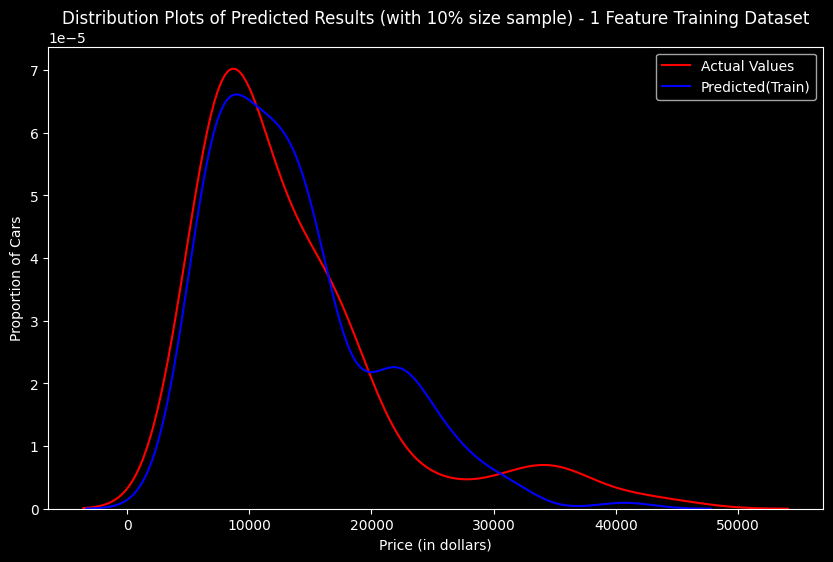

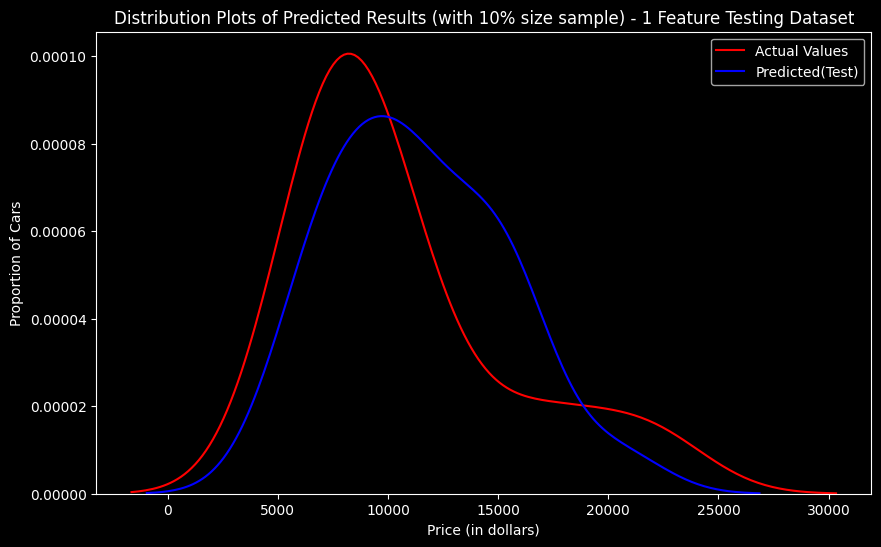

In [6]:
yhat_train = lm.predict(x_train[['horsepower']])
yhat_test  = lm.predict(x_test[['horsepower']])

Title = 'Distribution Plots of Predicted Results (with 10% size sample) - 1 Feature Training Dataset'
DistributionPlot(y_train, yhat_train, 'Actual Values','Predicted(Train)', Title)

Title = 'Distribution Plots of Predicted Results (with 10% size sample) - 1 Feature Testing Dataset'
DistributionPlot(y_test, yhat_test, 'Actual Values','Predicted(Test)', Title)

### Important Concept to Note:
* When we fit() the model with the training dataset, the model in this case generate a best fit regression line for the model. So not every data point will fall on the line.
* When we perfrom a score() using the same dataset, the model will compute the price based on the regression line function in the model. Then it compares the predicted price with the training dataset price and generate the percentage accuracy of the match. So in this case, we trained the model with the training data, and when we check the accuracy of the model using both the test dataset and training dataset, we found that with the test dataset only 36.35% of the predicted price matched the actual price. But for the training dataset, we get 66.20% matches. 

#### The wide difference in the score tells us that:
* Overfitting happens when the model learns the specific "noise" and "quirks" of the training data instead of the actual underlying relationship. 
    * It is memorizing the answer instead of looking for pattern.
* Lack of Generalization. 
    * A good model is one that generalizes well so it can perform well in a wide variety of scenarios.
* The model is inconsistent as its performance changes drastically depending on which data it is looking at.
* The generated regression line in the model is a bad fit. The feature (horsepower) used alone is not a reliable predictor.

#### How to interpret R-square:
* An R^2 of 1.0 (100%): The model is perfectly accurate. Every single data point falls exactly on the regression line.
* An R^2 of 0.70 (70%): The model is quite good. 70% of the variation in car prices can be explained by the horsepower.
* An R^2 of 0.0 (0%): The model is useless. Knowing the horsepower tells you absolutely nothing about the price.
* R2 (The Score) tells us how much the model gets right.
* MSE (Mean Squared Error) tells us how much (quantity) the model gets wrong.

#### <b>Exercise 2</b>: For comparison, create a Linear Regression model and train it with x_train1 dataset (the 40%-split data sample we generated earlier above) for feature = 'horsepower', and calculate the R Square value.

In [7]:
lm1 = LinearRegression()
lm1.fit(x_train1[['horsepower']], y_train1)

# compute the R^2 score for both the 40%-split sample Training and Test Dataset
print(f"R Square for 40%-split sample x_train1 data = {lm1.score(x_train1[['horsepower']], y_train1)}")
print(f"R Square for 40%-split sample x_test1  data = {lm1.score(x_test1[['horsepower']], y_test1)}")


R Square for 40%-split sample x_train1 data = 0.5754853866574969
R Square for 40%-split sample x_test1  data = 0.7139737368233016


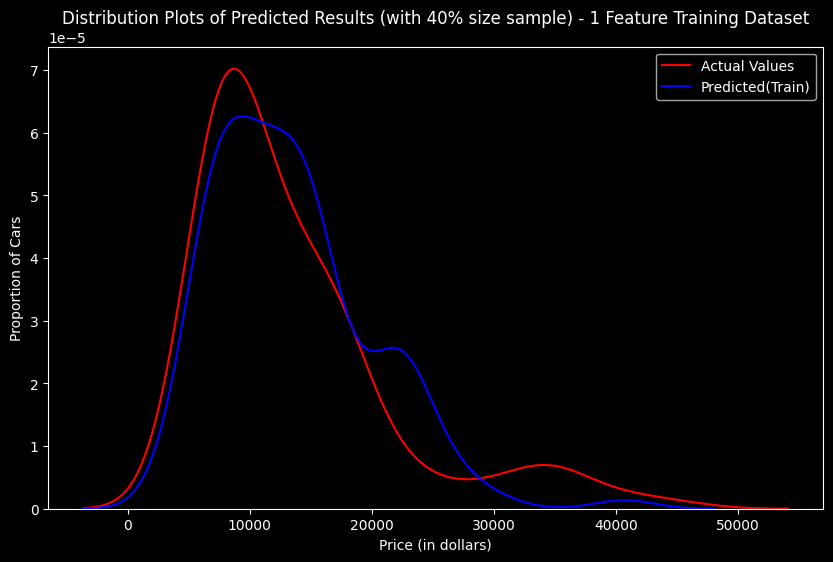

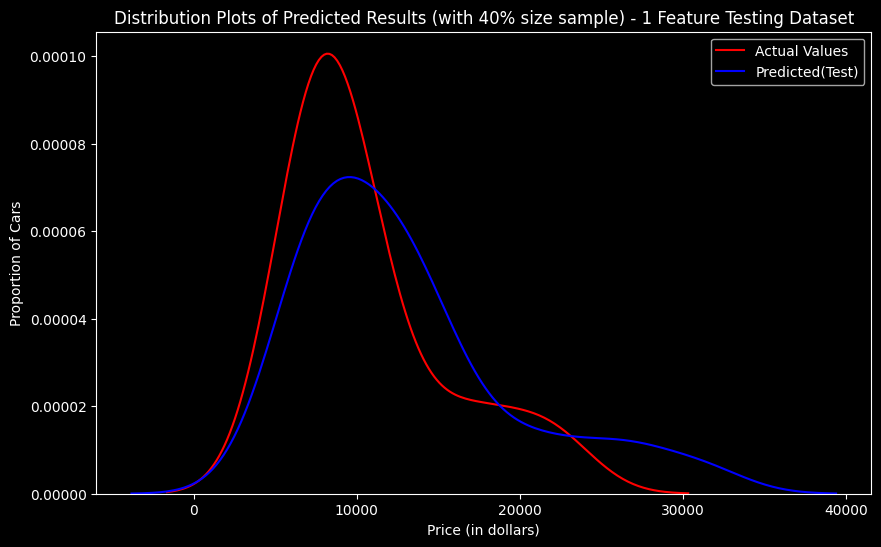

In [8]:
yhat_train1 = lm.predict(x_train1[['horsepower']])
yhat_test1  = lm.predict(x_test1[['horsepower']])

Title = 'Distribution Plots of Predicted Results (with 40% size sample) - 1 Feature Training Dataset'
DistributionPlot(y_train, yhat_train1, 'Actual Values','Predicted(Train)', Title)

Title = 'Distribution Plots of Predicted Results (with 40% size sample) - 1 Feature Testing Dataset'
DistributionPlot(y_test, yhat_test1, 'Actual Values','Predicted(Test)', Title)

The 40% sample size test data produces much closer R-square score between the traning and test dataset.
This confirms that the model's performance has a strong dependence on how the data was split. The distribution plots helps us to visualize it.

### Cross Validation
* Sometimes we do not have sufficient testing data and may want to perform cross-validation.
* The purpose of cross validation is to provide a more reliable and robust estimate of the model's performance by ensuring that every single data point gets a chance to be used for both training and testing.
* The full dataset is divided equally into equally sized group call fold.
* Some of the fold can be used as training set, and the remaining folds will be used as test set.
* For example in a 4 folds split, we can use 3 folds for training the model, and the remaining 1 fold for tesing.
* Then we can swap the folds for training and testing over several iterations.
* In the end, we can take the average of the results as the estimated out-of-sample error.
* We use the cross_val_score() function from sklearn.model_selection to help us do all the above computation.
* The function takes 4 parameters:
    * estimator - specify our model for this parameter
    * x - specify our x values predicting variable dataset
    * y - specify the y values of the target result dataset
    * cv - specify the number of folds
    * scoring - specify strategy to evaluate the model performance; use "neg_mean_squared_error" for negative squared error; default (None) uses scoring_api_overview
* The function returns RCross, which is an array of scores from the iteration it performs depending on the number folds.
* We can calculate the mean of the Cross Validation error, RCross.mean().
* We can also calculate the Std.Deviation, RCross.std().
* The mean is the "true" expected performance.
* The Standard Deviation indicates the uncertainty or risk in the model's performance.
    * a high std deviation means the model is inconsistent, meaning the predicted result deviate too much from the actual output when tested with different dataset.


### The Goal: You want these numbers to be as small as possible. 
* If these numbers are very large, it means the "horsepower" feature alone is not doing a great job of predicting the "price" accurately.
* By looking at the returned score's list of values (rather than just one), you can see if the model is consistent.
    * If your 4 MSE values are all very similar (e.g., [20.1, 19.8, 20.5, 20.2]), your model is stable. It performs predictably regardless of which dataset it's looking at.
    * If your 4 MSE values are wildly different (e.g., [10.5, 80.2, 15.1, 95.5]), your model is unstable. This usually means the model is very sensitive to specific data points (outliers) or that your dataset is too small for the model to find a reliable pattern.



In [9]:
from sklearn.model_selection import cross_val_score

# Input the object, the feature ('horsepower'), and the target data (y_data). Parameter 'cv' determines the number of folds.
Rcross = cross_val_score(lm, x_data[['horsepower']], y_data, cv=4) # returns an array of 4 R-Square values, one for each fold.
print(Rcross)

# calculate the average and std deviation of the estimate:
print(f"The mean of the folds are {Rcross.mean()}, and the std deviation is {Rcross.std()}")

# Use negative squared error as a score by setting the parameter 'scoring' metric to neg_mean_squared_error.
neg_mean_squared_errors = -1 * cross_val_score(lm, x_data[['horsepower']], y_data, cv=4, scoring='neg_mean_squared_error')  # returns an array of 4 positive mse values.
mean_squared_errors = cross_val_score(lm, x_data[['horsepower']], y_data, cv=4, scoring='neg_mean_squared_error')  # returns an array of mse values.
print("\nNegative Mean Squared Errors: \n", neg_mean_squared_errors)
print("\nMean Squared Errors: \n", mean_squared_errors)

[0.77465419 0.51718424 0.74814454 0.04825398]
The mean of the folds are 0.5220592359225414, and the std deviation is 0.29130480666118436

Negative Mean Squared Errors: 
 [20251357.7835463  43743920.05390439 12525158.34507633 17564549.69976653]

Mean Squared Errors: 
 [-20251357.7835463  -43743920.05390439 -12525158.34507633
 -17564549.69976653]


### Exercise 3: Calculate the average R-square using two folds, then find the average R-square for the second fold utilizing the 'horsepower' feature.

In [10]:
Rcross = cross_val_score(lm, x_data[['horsepower']], y_data, cv=2)
print(f"The mean of the folds are {Rcross.mean()}, and the std deviation is {Rcross.std()}")


# Use the function 'cross_val_predict' to predict the output. The function splits up the data into the specified number of folds, 
# with one fold for testing and the other folds are used for training.
from sklearn.model_selection import cross_val_predict
yhat = cross_val_predict(lm, x_data[['horsepower']], y_data, cv=4)
yhat



The mean of the folds are 0.516835099979672, and the std deviation is 0.07336982731492742


array([14142.23793549, 14142.23793549, 20815.3029844 , 12745.549902  ,
       14762.9881726 , 13987.05037621, 13987.05037621, 13987.05037621,
       18642.67715452, 12590.36234272, 12590.36234272, 15694.11352826,
       15694.11352826, 15694.11352826, 25160.55464415, 25160.55464415,
       25160.55464415,  4365.42170104,  7779.54800513,  7779.54800513,
        7469.17288658,  7469.17288658, 12745.549902  ,  7469.17288658,
        7469.17288658,  7469.17288658, 12745.549902  , 10572.92407212,
       19418.61495091,  5917.29729381,  8710.67336079,  6227.67241236,
        8710.67336079,  8710.67336079,  8710.67336079,  8710.67336079,
       10262.54895356, 10262.54895356, 10262.54895356, 10262.54895356,
       12590.36234272, 12435.17478344,  9021.04847935, 10883.29919067,
       24229.42928849, 24229.42928849, 37575.55938631,  7469.17288658,
        7469.17288658,  7469.17288658,  7469.17288658,  7192.02645193,
       12625.75925608, 12625.75925608, 12625.75925608, 18224.15063005,
      

### Part 2: Overfitting, Underfitting and Model Selection
* Underfitting
    * the model is too simple to fit the data. e.g. a simple regression line to fit a polynomial data curve points.
* Overfitting
    * the model is too complex for the data and unecassarily include outliers in its modeling, usually along areas where there is lack of data points.

<p>
It turns out that the test data, sometimes referred to as the "out of sample data", is a much better measure of how well our model performs in the real world. One reason for this is overfitting.

Let's go over some examples. It turns out these differences are more apparent in Multiple Linear Regression and Polynomial Regression so we will explore overfitting in that context.

Let's create Multiple Linear Regression objects and train the model using <b>'horsepower'</b>, <b>'curb-weight'</b>, <b>'engine-size'</b> and <b>'highway-mpg'</b> as features.

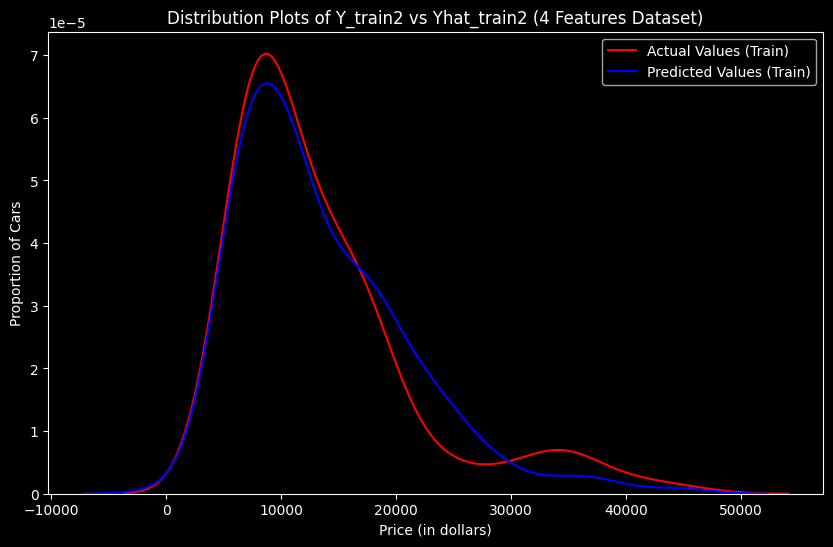

In [11]:
x_train2 = x_train[['horsepower','curb-weight','engine-size','highway-mpg']]
y_train2 = y_train
x_test2 = x_test[['horsepower','curb-weight','engine-size','highway-mpg']]
y_test2 = y_test

lr = LinearRegression()
lr.fit(x_train2, y_train2) # multi-features linear regression

yhat_train2 = lr.predict(x_train2)
yhat_test2  = lr.predict(x_test2)


Title = 'Distribution Plots of Y_train2 vs Yhat_train2 (4 Features Dataset)'
DistributionPlot(y_train2, yhat_train2, 'Actual Values (Train)','Predicted Values (Train)', Title)



We have trained our model using the training dataset. 

In the above figure, we show the distribution plots comparing the actual(red) vs the predicted(blue) output using the training dataset. Note that their distribution are very similar.

Let's take a look at the distribution plots when we use the testing data on the same model.

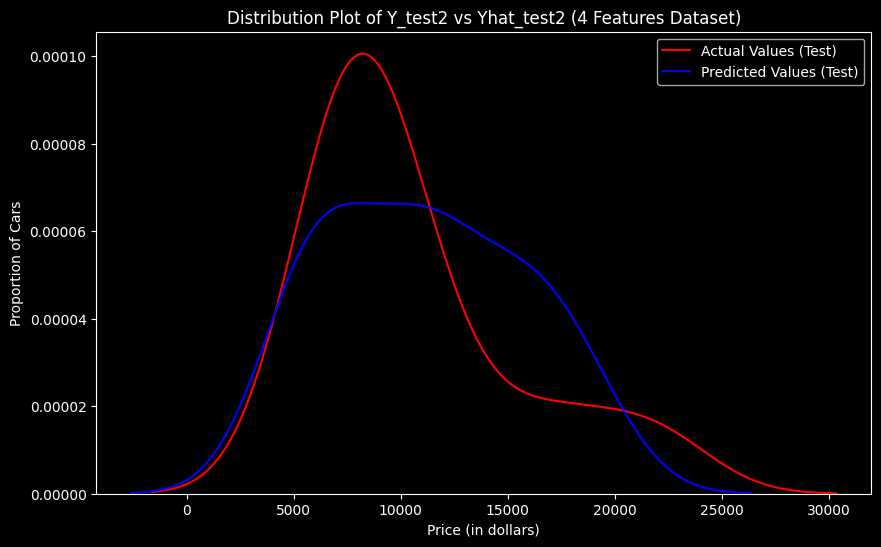

In [12]:
Title = 'Distribution Plot of Y_test2 vs Yhat_test2 (4 Features Dataset)'
DistributionPlot(y_test2, yhat_test2, 'Actual Values (Test)','Predicted Values (Test)', Title)



Here in the above figure, we used the test dataset for the prediction and the distribution plots between the actual(red) vs the predicted(blue) are relatively different.

Comparing the above with the previous figure, it is evident that the distribution of the test data in the above figure is much better at fitting the data. This difference in Figure 2 is apparent in the range of 5000 to 15,000. This is where the shape of the distribution is extremely different. Let's see if polynomial regression also exhibits a drop in the prediction accuracy when analysing the test dataset.


The difference is due to a generalization error and represent what we see in the real world.

Using a lot of data for training gives us an accurate means of determining how well our model will perform in the real world, but the precision of the performance will be low.

But if we use fewer data points to train the model and more to test the model, the accuracy of the generalization performance will be less, but the model will have good precision.

To overcome this problem, we use Cross Validation.


### Case 2 : Evaluation of a Polynomial Regression Model of 5th Degree with Single Feature

Predicted values: [ 6727.58219945  7306.70943225 12213.70783901 18895.03307984]
True values     : [ 6295. 10698. 13860. 13499.]
R-square (training data): 0.5568527853920284
R-square (test data)    : -29.815556299616322


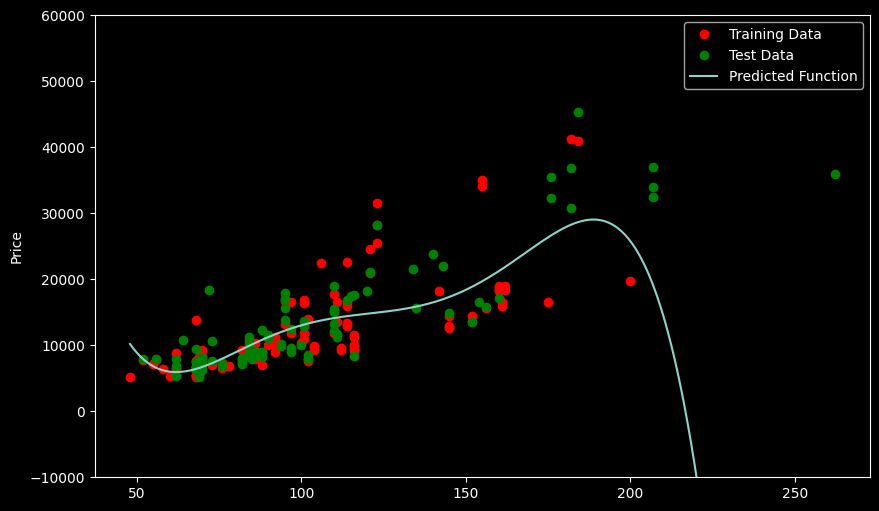

In [13]:
from sklearn.preprocessing import PolynomialFeatures

# 1. we first allocate the training and test data (45% in this case)
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.45, random_state=0)

# 2. generate new features datasets for a polynomial degree of 5
pr = PolynomialFeatures(degree=5)
x_train_pr = pr.fit_transform(x_train[['horsepower']])
x_test_pr  = pr.fit_transform(x_test[['horsepower']])

# 3. train and predict the model with polynomial features with the above polynomial features datasets.
poly = LinearRegression()
poly.fit(x_train_pr, y_train)
yhat = poly.predict(x_test_pr)

print(f"Predicted values: {yhat[0:4]}")
print(f"True values     : {y_test[0:4].values}")

# Plot the graph to show relationship of the generated polynomial features data points (test & train) and the model's function curve
PollyPlot(x_train['horsepower'], x_test['horsepower'], y_train, y_test, poly, pr)
# We see that the estimated function appears to track the data but around 200 horsepower, the function begins to diverge from the data points (symptom of overfitting).

print(f"R-square (training data): {poly.score(x_train_pr, y_train)}")
print(f"R-square (test data)    : {poly.score(x_test_pr, y_test)}")
# We see the R^2 for the training data is 0.5567 while the R^2 on the test data was -29.87. The lower the R^2, the worse the model. A negative R^2 is a sign of overfitting.





Text(3, 0.75, 'Maximum R^2 ')

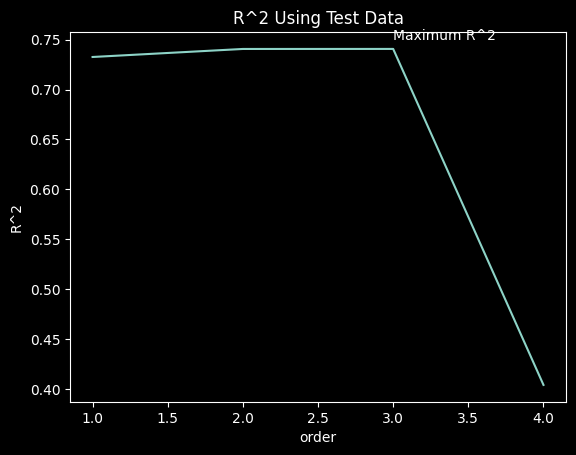

In [14]:
# Let's see how the R^2 changes on the test data for different order polynomials and then plot the results:

Rsqu_test = []

# the following loop generate data points for the R^2 score with different degree of polynomial featured data
order = [1, 2, 3, 4]
for n in order:
    pr = PolynomialFeatures(degree=n)
    x_train_pr = pr.fit_transform(x_train[['horsepower']])
    x_test_pr = pr.fit_transform(x_test[['horsepower']])    
    lr.fit(x_train_pr, y_train)
    Rsqu_test.append(lr.score(x_test_pr, y_test))

plt.plot(order, Rsqu_test)
plt.xlabel('order')
plt.ylabel('R^2')
plt.title('R^2 Using Test Data')
plt.text(3, 0.75, 'Maximum R^2 ')    

# We see the R^2 gradually increases until an order three polynomial is used. Then, the R^2 dramatically decreases at an order four polynomial.
# So it looks like degree 3 is the best for our polynomial features degree.




In [15]:
# here we define a function and used in a interactive UI to let us experiment different polynomial orders with different test size

def f(order, test_data):
    x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=test_data, random_state=0)
    pr = PolynomialFeatures(degree=order)
    x_train_pr = pr.fit_transform(x_train[['horsepower']])
    x_test_pr = pr.fit_transform(x_test[['horsepower']])
    poly = LinearRegression()
    poly.fit(x_train_pr,y_train)
    PollyPlot(x_train['horsepower'], x_test['horsepower'], y_train, y_test, poly,pr)


interact(f, order=(0, 6, 1), test_data=(0.05, 0.95, 0.05))

interactive(children=(IntSlider(value=3, description='order', max=6), FloatSlider(value=0.45, description='tes…

<function __main__.f(order, test_data)>

In [16]:
# Multiple Features with Polynomial of 2nd degree

# Question 4a :
# We can perform polynomial transformations with more than one feature. Create a 'PolynomialFeatures' object pr1 of degree 2.

pr1 = PolynomialFeatures(degree=2)

In [17]:
# Question 4b:
# Transform the training and testing samples for the features 'horsepower','curb-weight','engine-size','highway-mpg' . Use method 'fit_transform'.

x_train_pr1 = pr1.fit_transform(x_train[['horsepower','curb-weight','engine-size','highway-mpg']])
x_test_pr1  = pr1.fit_transform(x_test[['horsepower','curb-weight','engine-size','highway-mpg']])

In [18]:
# Question 4c:
# How many dimensions does the new feature have? use the attribute 'shape'.

print(x_train_pr1.shape)
print(x_test_pr1.shape)

(110, 15)
(91, 15)


In [19]:
# Question 4d:
# Create a linear regression model 'poly1'. Train the object using the method 'fit' using the polynomial features.

poly1 = LinearRegression()
poly1.fit(x_train_pr1, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


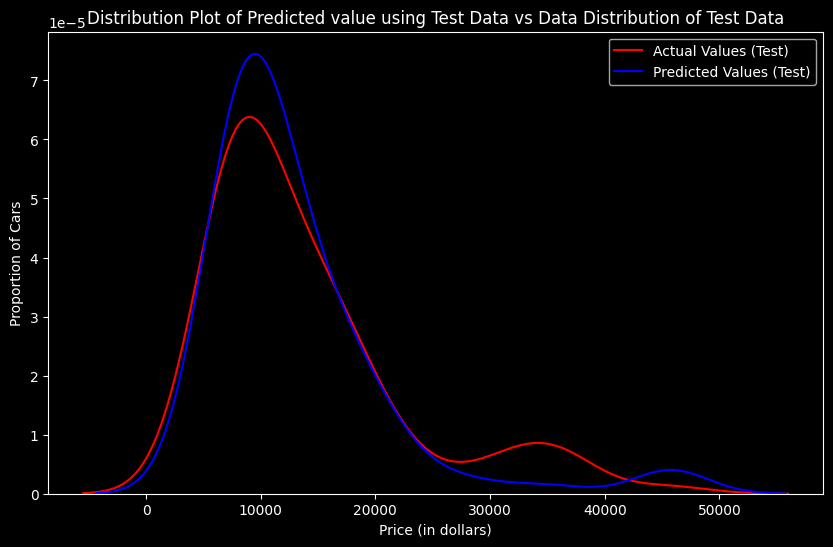

In [20]:
# Question 4e:
# Use the method 'predict' to predict an output on the polynomial features, then use the function 'DistributionPlot' to display the distribution of the predicted test output vs actual data.

yhat_test1 = poly1.predict(x_test_pr1)
Title='Distribution Plot of Predicted value using Test Data vs Data Distribution of Test Data'
DistributionPlot(y_test, yhat_test1, 'Actual Values (Test)','Predicted Values (Test)', Title)

In [21]:
# Question 4f:
# Using the distribution plot above, describe the two regions where the predicted prices are less accurate than the actual prices.

# The predicted value is higher than actual value for cars where the price $10,000 range, conversely the predicted price is lower than the 
# price cost in the $30,000 to $40,000 range. As such the model is not as accurate in these ranges.


In [22]:
# Ridge Regression
# For models with multiple independent features and ones with polynomial feature extrapolation, it is common to have colinear combinations of features. 
# Left unchecked, this multicollinearity of features can lead the model to overfit the training data. To control this, the feature sets are typically 
# regularized using hyperparameters.
# Ridge regression is the process of regularizing the feature set using the hyperparameter alpha. Ridge regression can be utilized to regularize and 
# reduce standard errors and avoid over-fitting while using a regression model. This is done through a parameter called alpha.
# If alpha is too large, we will get a overfitting model. If alpha is zero, the overfitting is evident. For alpha equals to 0.001 the overfitting
# begins to subside. For alpha equals 0.01, the estimated function tracks the actual function. When alpha equals 1, we see the first sign of underfitting and
# the estimated function does not have enough flexibility. 
# In order to select alpha, we use cross validation.

# create train & test datasets with polynomial features for multiple features
pr = PolynomialFeatures(degree=2)
x_train_pr = pr.fit_transform(x_train[['horsepower','curb-weight','engine-size','highway-mpg','normalized-losses','symboling']])
x_test_pr  = pr.fit_transform( x_test[['horsepower','curb-weight','engine-size','highway-mpg','normalized-losses','symboling']])


from sklearn.linear_model import Ridge

RidgeModel = Ridge(alpha=1) # create an instance of the model with alpha=1
RidgeModel.fit(x_train_pr, y_train)
yhat = RidgeModel.predict(x_test_pr)

# comparing first five predicted vs test values
with np.printoptions(precision=0):
    print(f"predicted: {yhat[0:4]}")
    print(f"test set: {y_test[0:4].values}")


predicted: [ 6572.  9634. 20948. 19403.]
test set: [ 6295. 10698. 13860. 13499.]


100%|██████████| 1000/1000 [00:01<00:00, 536.35it/s, Test Score=0.564, Train Score=0.859]


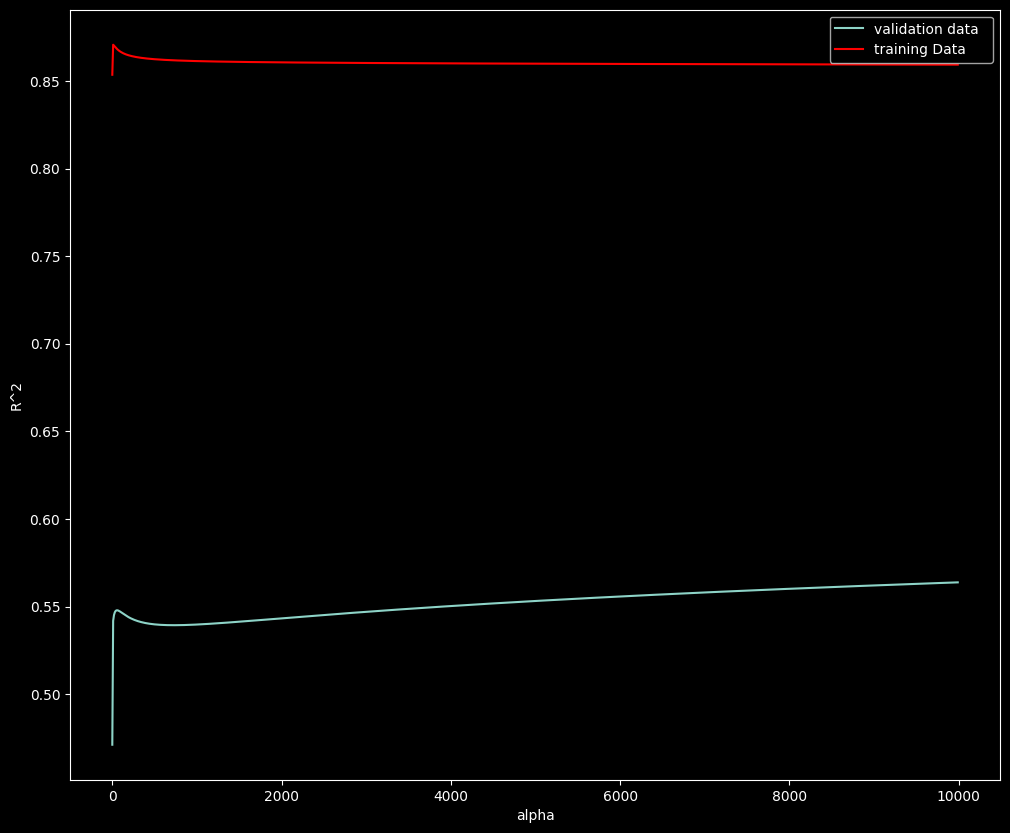

In [23]:
# To select the value of alpha that minimizes the test error (R^2), we use a for loop to compute the test and train R^2 scores.
# Then we can graph the scores against different alpha values.

from tqdm import tqdm

Rsqu_test = []
Rsqu_train = []
dummy1 = []
Alpha = 10 * np.array(range(0,1000))
pbar = tqdm(Alpha)

for alpha in pbar:
    RigeModel = Ridge(alpha=alpha) 
    RigeModel.fit(x_train_pr, y_train)
    test_score, train_score = RigeModel.score(x_test_pr, y_test), RigeModel.score(x_train_pr, y_train)
    
    pbar.set_postfix({"Test Score": test_score, "Train Score": train_score})

    Rsqu_test.append(test_score)
    Rsqu_train.append(train_score)


# plotting out the value of R-square for different alphas:
width = 12
height = 10
plt.figure(figsize=(width, height))

plt.plot(Alpha,Rsqu_test, label='validation data  ')
plt.plot(Alpha,Rsqu_train, 'r', label='training Data ')
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.legend()


# The blue line represents the R^2 of the validation data, and the red line represents the R^2 of the training data. The x-axis represents the different values of Alpha.
# Here the model is built and tested on the same data, so the training and test data are the same.
# The red line in Figure below represents the R^2 of the training data. As alpha increases the R^2 decreases. Therefore, as alpha increases, the model performs worse on the training data
# The blue line represents the R^2 on the validation data. As the value for alpha increases, the R^2 increases and converges at a point.


In [24]:
# Question 5: 
# Perform Ridge regression. Calculate the R^2 using the polynomial features, use the training data to train the model and use the test data to test the model.
# The parameter alpha should be set to 10.


RigeModel = Ridge(alpha=10) 
RigeModel.fit(x_train_pr, y_train)
RigeModel.score(x_test_pr, y_test) # R^2



0.5418333518676055

In [25]:
# Grid Search
# The term alpha is a hyperparameter. Sklearn has the class GridSearchCV to make the process of finding the best hyperparameter simpler.

from sklearn.model_selection import GridSearchCV

parameters1 = [{'alpha': [0.001,0.1,1,10,100,1000,10000,100000,1000000]}]
print(parameters1)

RR = Ridge()
Grid1 = GridSearchCV(RR, parameters1, cv=4)
Grid1.fit(x_data[['horsepower','curb-weight','engine-size','highway-mpg']], y_data)

BestRR = Grid1.best_estimator_
print(BestRR)

print(f"Grid1.cv_results contains : {list(Grid1.cv_results_)}")
print(f"Grid1.best_params_ contains : {list(Grid1.best_params_)}")

print(f"Best fit alpha: {Grid1.best_params_['alpha']}") # the best fit alpha is stored in this object
print(f"Score (training data): {BestRR.score(x_data[['horsepower','curb-weight','engine-size','highway-mpg']], y_data):.2f}")


# test our model on the test data
print(f"Score (test data): {BestRR.score(x_test[['horsepower','curb-weight','engine-size','highway-mpg']], y_test):.2f}")


[{'alpha': [0.001, 0.1, 1, 10, 100, 1000, 10000, 100000, 1000000]}]
Ridge(alpha=10000)
Grid1.cv_results contains : ['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_alpha', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score']
Grid1.best_params_ contains : ['alpha']
Best fit alpha: 10000
Score (training data): 0.81
Score (test data): 0.84


In [26]:
# Question 6: Perform a grid search to find the best alpha value and check if using feature scaling improves the model.

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_data[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']])

# Define parameter grid without 'normalize'
parameters2 = [{'alpha': [0.001, 0.1, 1, 10, 100, 1000, 10000, 100000, 1000000]}]

# Perform Grid Search
Grid2 = GridSearchCV(Ridge(), parameters2, cv=4)
Grid2.fit(x_scaled, y_data)

# Best model
best_ridge_model = Grid2.best_estimator_
best_alpha = Grid2.best_params_['alpha']
best_alpha
print(f"Best fit alpha: {Grid2.best_params_['alpha']}") 
print(f"Score (training data): {best_ridge_model.score(x_scaled, y_data):.2f}")

# To use Ridge Regression correctly, it must be trained with normalized/standardized data.

Best fit alpha: 100
Score (training data): 0.78


In [27]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

# 1. Create a Pipeline that scales then runs Ridge
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

# 2. Update parameter names to match the pipeline (step__parameter)
parameters = [{'ridge__alpha': [0.001, 0.1, 1, 10, 100, 1000, 10000]}]

# 3. Run GridSearch
grid = GridSearchCV(pipe, parameters, cv=4)
grid.fit(x_data[['horsepower','curb-weight','engine-size','highway-mpg']], y_data)

print(f"Correctly scaled best alpha: {grid.best_params_['ridge__alpha']}")

Correctly scaled best alpha: 100
